# Used Car Price Prediction Notebook

This notebook follows the required task structure and is prepared for the supplied used-car dataset.

## Workflow

- Data loading and inspection
- Data cleaning
- Feature engineering
- Encoding and scaling
- Train / validation / test split
- Regression model comparison and validation
- Held-out test evaluation
- Hidden-set compatible `predict_price(df)` interface

## 0. Setup

Standard imports and file paths are set up below.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

TRAIN_PATH = "data.csv"
TARGET_COLUMN = "price"
EVALUATION_SPLIT_PATH = "./evaluation_split_task2.csv"

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 1. Load the Data

Load the dataset from `TRAIN_PATH` into a dataframe.

In [2]:
df = pd.read_csv(TRAIN_PATH)
print("Shape:", df.shape)
display(df.head())

Shape: (3207, 12)


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,BMW,M235 i,2015,"81,000 mi.",Gasoline,320.0HP 3.0L Straight 6 Cylinder Engine Gasoli...,6-Speed M/T,White,Red,None reported,Yes,"$27,890"
1,BMW,750 i,2017,"24,650 mi.",Gasoline,445.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Black,None reported,Yes,"$50,000"
2,Aston,Martin V8 Vantage Base,2008,"62,378 mi.",Gasoline,380.0HP 4.3L 8 Cylinder Engine Gasoline Fuel,M/T,Red,Beige,At least 1 accident or damage reported,Yes,"$33,995"
3,INFINITI,QX80 Luxe,2022,"49,860 mi.",Gasoline,5.6L V8 32V GDI DOHC,Automatic,Black Obsidian,Graphite,At least 1 accident or damage reported,Yes,"$47,645"
4,Subaru,BRZ Premium,2023,"5,800 mi.",Gasoline,228.0HP 2.4L 4 Cylinder Engine Gasoline Fuel,6-Speed M/T,Black,Black,None reported,Yes,"$29,990"


## 2. Explore and Clean the Dataset

The dataset contains categorical and string-formatted numerical fields. Missing categorical values are handled by the modeling pipeline. Duplicate rows are removed, target prices are converted to numeric values, and unusable target rows are removed.

,missing_values
clean_title,479
fuel_type,126
accident,92


Rows before cleaning: 3207
Rows after cleaning: 3207
Duplicate rows removed: 0
Price range: 2000 to 2954083


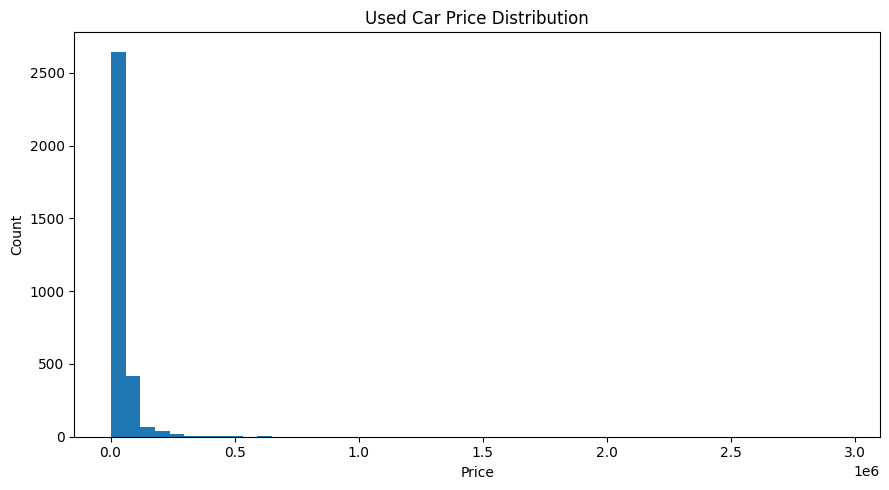

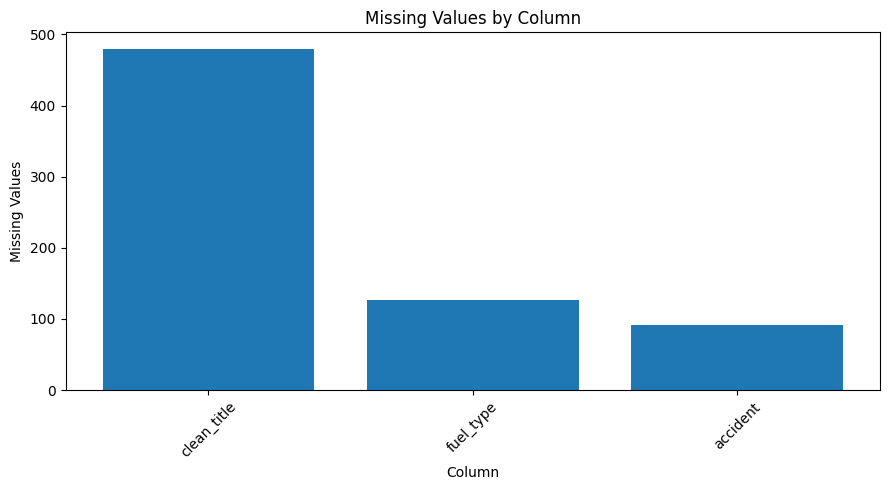

In [3]:
def data_cleaning(df):
    df = df.copy()
    df = df.drop_duplicates().reset_index(drop=True)
    if TARGET_COLUMN in df.columns:
        df[TARGET_COLUMN] = pd.to_numeric(
            df[TARGET_COLUMN].astype(str).str.replace(r"[$,]", "", regex=True),
            errors="coerce"
        )
        df = df.dropna(subset=[TARGET_COLUMN]).reset_index(drop=True)
    df["model_year"] = pd.to_numeric(df["model_year"], errors="coerce")
    return df

clean_preview = data_cleaning(df)

missing_summary = clean_preview.isna().sum().sort_values(ascending=False)
display(missing_summary[missing_summary > 0].to_frame("missing_values"))

print("Rows before cleaning:", len(df))
print("Rows after cleaning:", len(clean_preview))
print("Duplicate rows removed:", len(df) - len(df.drop_duplicates()))
print("Price range:", clean_preview[TARGET_COLUMN].min(), "to", clean_preview[TARGET_COLUMN].max())

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(clean_preview[TARGET_COLUMN], bins=50)
ax.set_xlabel("Price")
ax.set_ylabel("Count")
ax.set_title("Used Car Price Distribution")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
missing_plot = missing_summary[missing_summary > 0]
ax.bar(missing_plot.index, missing_plot.values)
ax.set_xlabel("Column")
ax.set_ylabel("Missing Values")
ax.set_title("Missing Values by Column")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 3. Feature Engineering

String-formatted mileage and engine specifications are converted into numerical features. Vehicle age, mileage per year, and log mileage are added. The original high-noise engine and mileage strings are removed after extraction. `clean_title` is removed because it contains only one observed category in the supplied data.

,brand,model,model_year,fuel_type,transmission,ext_col,int_col,accident,price,milage_num,engine_hp,engine_liters,engine_cylinders,vehicle_age,log_milage,mileage_per_year
0,BMW,M235 i,2015,Gasoline,6-Speed M/T,White,Red,None reported,27890,81000.0,320.0,3.0,6.0,11,11.302217,7363.636364
1,BMW,750 i,2017,Gasoline,A/T,Silver,Black,None reported,50000,24650.0,445.0,4.4,8.0,9,10.112573,2738.888889
2,Aston,Martin V8 Vantage Base,2008,Gasoline,M/T,Red,Beige,At least 1 accident or damage reported,33995,62378.0,380.0,4.3,8.0,18,11.040984,3465.444444
3,INFINITI,QX80 Luxe,2022,Gasoline,Automatic,Black Obsidian,Graphite,At least 1 accident or damage reported,47645,49860.0,NaN,5.6,NaN,4,10.816994,12465.000000
4,Subaru,BRZ Premium,2023,Gasoline,6-Speed M/T,Black,Black,None reported,29990,5800.0,228.0,2.4,4.0,3,8.665786,1933.333333


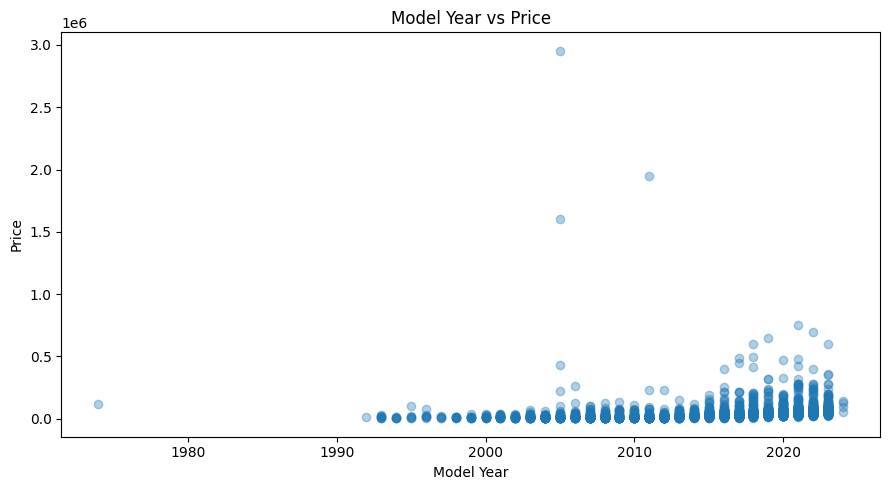

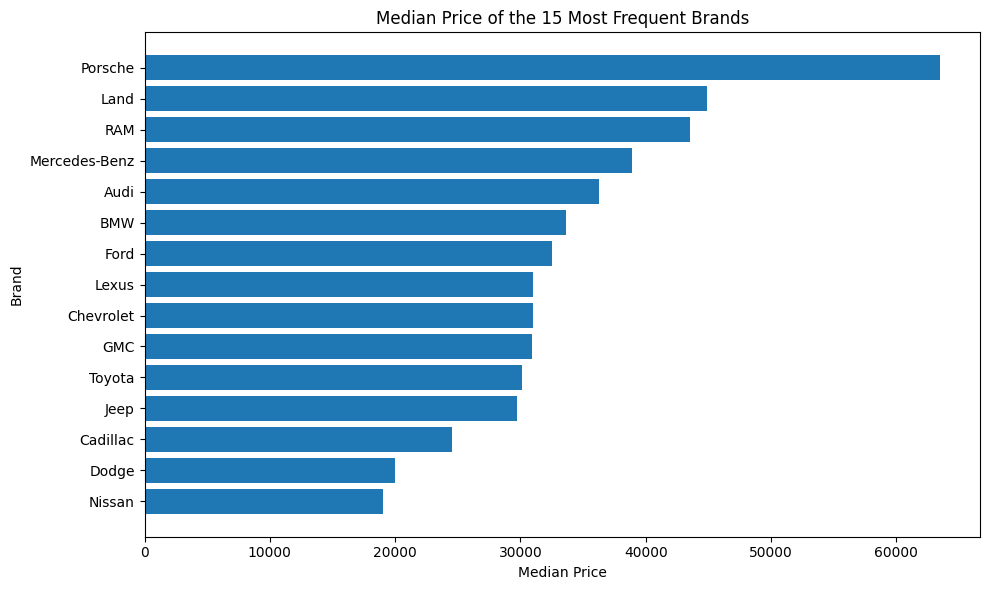

In [4]:
def feature_engineering(df):
    df = df.copy()

    df["milage_num"] = pd.to_numeric(
        df["milage"].astype(str).str.replace(r"[^\d.]", "", regex=True),
        errors="coerce"
    )

    engine_text = df["engine"].astype(str)

    df["engine_hp"] = pd.to_numeric(
        engine_text.str.extract(r"(\d+(?:\.\d+)?)HP", expand=False),
        errors="coerce"
    )

    df["engine_liters"] = pd.to_numeric(
        engine_text.str.extract(r"(\d+(?:\.\d+)?)L", expand=False),
        errors="coerce"
    )

    df["engine_cylinders"] = pd.to_numeric(
        engine_text.str.extract(r"(\d+)\s*Cylinder", expand=False),
        errors="coerce"
    )

    df["vehicle_age"] = 2026 - df["model_year"]
    df["vehicle_age"] = df["vehicle_age"].clip(lower=0)
    df["log_milage"] = np.log1p(df["milage_num"].clip(lower=0))
    df["mileage_per_year"] = df["milage_num"] / df["vehicle_age"].clip(lower=1)

    df = df.drop(columns=["milage", "engine", "clean_title"], errors="ignore")
    return df

feature_preview = feature_engineering(clean_preview)
display(feature_preview.head())

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(feature_preview["model_year"], clean_preview[TARGET_COLUMN], alpha=0.35)
ax.set_xlabel("Model Year")
ax.set_ylabel("Price")
ax.set_title("Model Year vs Price")
plt.tight_layout()
plt.show()

top_brands = clean_preview["brand"].value_counts().head(15).index
brand_prices = clean_preview[clean_preview["brand"].isin(top_brands)].groupby("brand")[TARGET_COLUMN].median().sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(brand_prices.index, brand_prices.values)
ax.set_xlabel("Median Price")
ax.set_ylabel("Brand")
ax.set_title("Median Price of the 15 Most Frequent Brands")
plt.tight_layout()
plt.show()

## 4. Transform, Normalize, and Scale Features

Numerical features use median imputation and standardization. Categorical features use most-frequent imputation and one-hot encoding with unknown-category protection and rare-category grouping.

In [5]:
preprocessor = None

def scale_features(df):
    global preprocessor

    if preprocessor is None:
        raise RuntimeError("The fitted preprocessing pipeline is not ready.")

    return preprocessor.transform(df)

def build_preprocessor(X):
    numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
    categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", min_frequency=2))
    ])

    return ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ])

In [6]:
def preprocess_data(df):
    df = df.copy()
    df = data_cleaning(df)
    df = feature_engineering(df)
    if TARGET_COLUMN in df.columns:
        df = df.drop(columns=[TARGET_COLUMN])
    return scale_features(df)

## 5. Train / Validation / Test Split

The data is split into training, validation, and test sets before fitting the preprocessing pipeline. The test set remains untouched until final evaluation.

In [7]:
def split_data(df):
    cleaned = data_cleaning(df)
    train_split, temp_split = train_test_split(
        cleaned,
        test_size=0.30,
        random_state=42
    )
    validation_split, test_split = train_test_split(
        temp_split,
        test_size=0.50,
        random_state=42
    )
    return train_split, validation_split, test_split

train_split, validation_split, test_split = split_data(df)

print("Train:", train_split.shape)
print("Validation:", validation_split.shape)
print("Test:", test_split.shape)

Train: (2244, 12)
Validation: (481, 12)
Test: (482, 12)


## 6. Model Training, and Hyperparameter Tuning

Ridge, Random Forest, and Extra Trees regressors are compared on the validation set. The selected model is then refit on the combined train and validation data before the held-out test evaluation.

In [8]:
train_features = feature_engineering(train_split)
validation_features = feature_engineering(validation_split)
test_features = feature_engineering(test_split)

X_train = train_features.drop(columns=[TARGET_COLUMN])
y_train = train_features[TARGET_COLUMN]

X_validation = validation_features.drop(columns=[TARGET_COLUMN])
y_validation = validation_features[TARGET_COLUMN]

X_test = test_features.drop(columns=[TARGET_COLUMN])
y_test = test_features[TARGET_COLUMN]

preprocessor = build_preprocessor(X_train)
preprocessor.fit(X_train)

X_train_processed = preprocess_data(train_split)
X_validation_processed = preprocess_data(validation_split)

models = {
    "Ridge": Ridge(alpha=10),
    "Random Forest": RandomForestRegressor(
        n_estimators=250,
        max_features=0.8,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=300,
        max_features=0.6,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
}

validation_results = []

for name, candidate in models.items():
    candidate.fit(X_train_processed, y_train)
    prediction = candidate.predict(X_validation_processed)
    validation_results.append({
        "Model": name,
        "RMSE": np.sqrt(mean_squared_error(y_validation, prediction)),
        "MAE": mean_absolute_error(y_validation, prediction),
        "R2": r2_score(y_validation, prediction)
    })

validation_results = pd.DataFrame(validation_results).sort_values("RMSE").reset_index(drop=True)
display(validation_results)

best_model_name = validation_results.loc[0, "Model"]
print("Selected model:", best_model_name)

combined_train = pd.concat([train_split, validation_split], ignore_index=True)
combined_features = feature_engineering(combined_train)
X_combined = combined_features.drop(columns=[TARGET_COLUMN])
y_combined = combined_features[TARGET_COLUMN]

preprocessor = build_preprocessor(X_combined)
preprocessor.fit(X_combined)

X_combined_processed = preprocess_data(combined_train)
X_test_processed = preprocess_data(test_split)

model = models[best_model_name]
model.fit(X_combined_processed, y_combined)

def predict_price(df):
    processed = preprocess_data(df)
    predictions = model.predict(processed)
    return predictions

,Model,RMSE,MAE,R2
0,Extra Trees,14942.503285,8183.822003,0.854550
1,Random Forest,24811.511536,10784.688050,0.598974
2,Ridge,31291.301029,19127.419448,0.362157


Selected model: Extra Trees


## 7. Evaluate on the Held-Out Test Set

Run `predict_price()` on the held-out test split and report RMSE, MAE, and R².

--- Metrics ---
      RMSE: 32975.7924
       MAE: 11464.0241
        R2: 0.6732


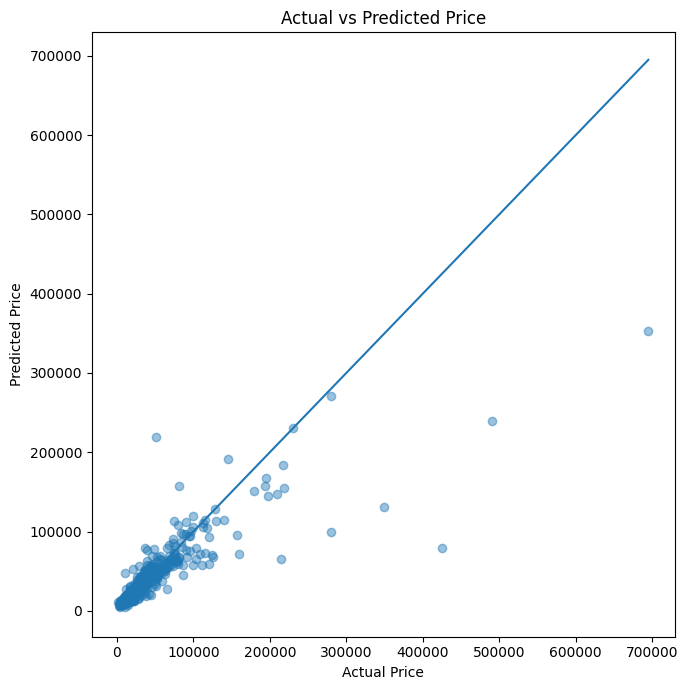

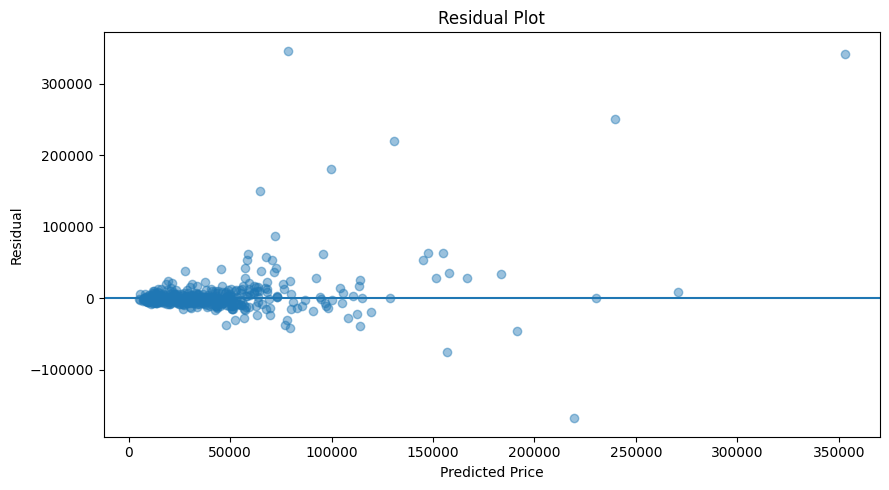

,Actual,Predicted,Absolute_Error
0,9000,10039.306111,1039.306111
1,18000,21464.865000,3464.865000
2,34900,27352.940000,7547.060000
3,4500,9328.956389,4828.956389
4,10000,48229.456167,38229.456167
5,57000,65753.660278,8753.660278
6,41900,36619.509389,5280.490611
7,29430,31533.114611,2103.114611
8,21000,24124.304667,3124.304667
9,21998,23004.503889,1006.503889


In [9]:
def evaluate_predictions(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    metrics = {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
    }
    print("--- Metrics ---")
    for name, value in metrics.items():
        print(f"{name:>10}: {value:.4f}")
    return metrics

test_predictions = predict_price(test_split.drop(columns=[TARGET_COLUMN]))
test_metrics = evaluate_predictions(y_test, test_predictions)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, test_predictions, alpha=0.45)
lower = min(y_test.min(), test_predictions.min())
upper = max(y_test.max(), test_predictions.max())
ax.plot([lower, upper], [lower, upper])
ax.set_xlabel("Actual Price")
ax.set_ylabel("Predicted Price")
ax.set_title("Actual vs Predicted Price")
plt.tight_layout()
plt.show()

residuals = y_test.to_numpy() - test_predictions

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(test_predictions, residuals, alpha=0.45)
ax.axhline(0)
ax.set_xlabel("Predicted Price")
ax.set_ylabel("Residual")
ax.set_title("Residual Plot")
plt.tight_layout()
plt.show()

prediction_table = pd.DataFrame({
    "Actual": y_test.to_numpy(),
    "Predicted": test_predictions,
    "Absolute_Error": np.abs(y_test.to_numpy() - test_predictions)
})
display(prediction_table.head(10))

---
## 8. Standardized Evaluation — DO NOT MODIFY

Everything below is run by the organizers for every submission. It loads the hidden evaluation set and scores your submission. Make sure your notebook runs top-to-bottom.

In [10]:
# =====================================================================
# ORGANIZER EVALUATION CELL — DO NOT MODIFY
# =====================================================================
assert "predict_price" in dir(), (
    "predict_price(df) is not defined. Your submission must define this "
    "function in Section 6 (see instructions there)."
)

evaluation_df = pd.read_csv(EVALUATION_SPLIT_PATH)
X_hidden = evaluation_df.drop(columns=[TARGET_COLUMN])
y_hidden = evaluation_df[TARGET_COLUMN]

y_pred = predict_price(X_hidden)

evaluation_metrics = evaluate_predictions(y_hidden, y_pred)
pd.DataFrame([evaluation_metrics])

--- Metrics ---
      RMSE: 32975.7924
       MAE: 11464.0241
        R2: 0.6732


,RMSE,MAE,R2
0,32975.792449,11464.024138,0.673196
